# Part 1

# Mounting the Google Drive

In [ ]:
# Mounting Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Load needed python resources
!pip install datascience
from datascience import *
import matplotlib
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
matplotlib.use('Agg')
%matplotlib inline
import math
from scipy import stats
import numpy as np
import warnings
np.set_printoptions(threshold=50)


In [ ]:
pwd

'/content'

In [ ]:
cd /content/drive/MyDrive/Colab\ Notebooks/Data

/content/drive/MyDrive/Colab Notebooks/Data


In [ ]:
ls

airlines.csv  airports.csv  flights.csv


In [ ]:
# This code only works if flights.csv is in the current working directory (see above)
flights = Table.read_table('flights.csv')

/usr/local/lib/python3.12/dist-packages/datascience/tables.py:163: DtypeWarning: Columns (7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pandas.read_csv(filepath_or_buffer, *args, **vargs)


After running the preamble and mounting the google drive into the colab file, I was able to check the directory of the folder, read the folder with the Kaggle files into the colab file, and finally read the flights table with the previous line of code.

# Part 2

In [ ]:
gap = 7500
start = np.random.choice(np.arange(gap))
mySample = flights.take(np.arange(start, flights.num_rows, gap))
print(mySample.num_rows)
mySample

776


YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
2015,1,1,4,AA,1288,N568AA,DFW,SAN,1225,1227,2,19,1246,190,190,169,1171,1335,2,1335,1337,2,0,0,nan,nan,nan,nan,nan,nan
2015,1,1,4,AA,2481,N403AA,DFW,MFE,2055,2134,39,14,2148,90,93,75,469,2303,4,2225,2307,42,0,0,nan,3,0,39,0,0
2015,1,2,5,B6,114,N554JB,FLL,HPN,1145,1144,-1,14,1158,173,162,145,1097,1423,3,1438,1426,-12,0,0,nan,nan,nan,nan,nan,nan
2015,1,2,5,DL,1296,N937DN,ATL,PIT,1910,1912,2,21,1933,104,96,69,526,2042,6,2054,2048,-6,0,0,nan,nan,nan,nan,nan,nan
2015,1,3,6,WN,2203,N256WN,SNA,LAS,1025,1016,-9,8,1024,65,57,43,226,1107,6,1130,1113,-17,0,0,nan,nan,nan,nan,nan,nan
2015,1,3,6,WN,1929,N736SA,BWI,BNA,1825,1917,52,9,1926,120,106,91,587,1957,6,1925,2003,38,0,0,nan,0,0,12,26,0
2015,1,4,7,AA,2315,N434AA,ORD,DFW,955,1038,43,19,1057,155,151,126,802,1303,6,1230,1309,39,0,0,nan,0,0,0,0,39
2015,1,4,7,DL,1678,N905DE,ATL,BWI,1725,1721,-4,13,1734,109,102,82,577,1856,7,1914,1903,-11,0,0,nan,nan,nan,nan,nan,nan
2015,1,5,1,WN,1338,N451WN,MDW,CLE,820,922,62,14,936,75,67,47,307,1123,6,1035,1129,54,0,0,nan,0,0,35,19,0
2015,1,5,1,US,483,N812AW,AUS,PHX,1543,1543,0,10,1553,147,143,125,872,1658,8,1710,1706,-4,0,0,nan,nan,nan,nan,nan,nan


A simple random sample gives every member of a population an equal chance of being selected, minimizing bias and providing representative results. A systematic sample selects participants at regular intervals from a randomly chosen starting point, offering a generally good representation unless hidden patterns in the population create bias. A convenience sample involves choosing easily accessible participants, resulting in high bias and poor representation of the broader population.

# Part 3

In [ ]:
airports = Table.read_table('airports.csv')

In [ ]:
mySample = (flights.take(np.arange(start, flights.num_rows, gap))
                   .join('ORIGIN_AIRPORT', airports, 'IATA_CODE')
                   .select('MONTH', 'DAY', 'ORIGIN_AIRPORT',
                           'DESTINATION_AIRPORT', 'SCHEDULED_DEPARTURE',
                           'DEPARTURE_DELAY', 'AIRPORT',
                           'LATITUDE', 'LONGITUDE')
                   .relabeled('ORIGIN_AIRPORT', 'ORIGIN')
                   .relabeled('DESTINATION_AIRPORT', 'DESTINATION')
                   .relabeled('DEPARTURE_DELAY', 'DELAY')
                   .relabeled('AIRPORT', 'ORIGIN_NAME')
            )
print(mySample.num_rows)
mySample

712


MONTH,DAY,ORIGIN,DESTINATION,SCHEDULED_DEPARTURE,DELAY,ORIGIN_NAME,LATITUDE,LONGITUDE
8,18,ABE,ATL,615,5,Lehigh Valley International Airport,40.6524,-75.4404
7,30,ABQ,DAL,1005,12,Albuquerque International Sunport,35.0402,-106.609
5,14,ACT,DFW,525,25,Waco Regional Airport,31.6113,-97.2305
4,17,ACV,SFO,2006,27,Arcata Airport,40.9781,-124.109
4,19,AGS,ATL,1315,15,Augusta Regional Airport (Bush Field),33.37,-81.9645
1,25,ALO,ORD,1510,nan,Waterloo Regional Airport,42.5571,-92.4003
2,11,ANC,PHX,2330,0,Ted Stevens Anchorage International Airport,61.1743,-149.996
3,17,ANC,SCC,745,-2,Ted Stevens Anchorage International Airport,61.1743,-149.996
6,12,ANC,SEA,240,-1,Ted Stevens Anchorage International Airport,61.1743,-149.996
1,2,ATL,PIT,1910,2,Hartsfield-Jackson Atlanta International Airport,33.6404,-84.4269


# Part 4

In [ ]:
mySample = mySample.with_column(
             'APPROX_DAY_OF_YEAR',
             30*(mySample.column('MONTH')-1) + mySample.column('DAY'))
mySample

MONTH,DAY,ORIGIN,DESTINATION,SCHEDULED_DEPARTURE,DELAY,ORIGIN_NAME,LATITUDE,LONGITUDE,APPROX_DAY_OF_YEAR
8,18,ABE,ATL,615,5,Lehigh Valley International Airport,40.6524,-75.4404,228
7,30,ABQ,DAL,1005,12,Albuquerque International Sunport,35.0402,-106.609,210
5,14,ACT,DFW,525,25,Waco Regional Airport,31.6113,-97.2305,134
4,17,ACV,SFO,2006,27,Arcata Airport,40.9781,-124.109,107
4,19,AGS,ATL,1315,15,Augusta Regional Airport (Bush Field),33.37,-81.9645,109
1,25,ALO,ORD,1510,nan,Waterloo Regional Airport,42.5571,-92.4003,25
2,11,ANC,PHX,2330,0,Ted Stevens Anchorage International Airport,61.1743,-149.996,41
3,17,ANC,SCC,745,-2,Ted Stevens Anchorage International Airport,61.1743,-149.996,77
6,12,ANC,SEA,240,-1,Ted Stevens Anchorage International Airport,61.1743,-149.996,162
1,2,ATL,PIT,1910,2,Hartsfield-Jackson Atlanta International Airport,33.6404,-84.4269,2


# Part 5

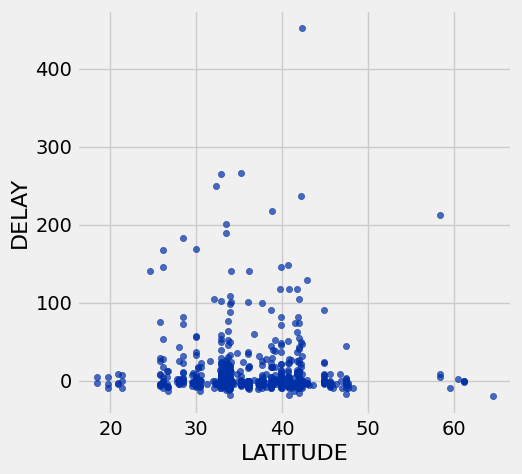

In [ ]:
mySample.scatter('LATITUDE', 'DELAY')

# Part 6

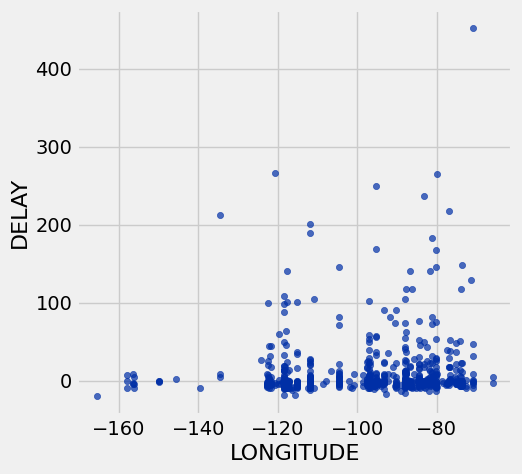

In [ ]:
mySample.scatter('LONGITUDE', 'DELAY')

The two scatterplots, LATITUDE vs. DELAY and LONGITUDE vs. DELAY, don't reveal any strong or obvious linear relationships between geographical location and flight departure delays. There doesn't seem to be a clear trend indicating that flights originating from airports at certain latitudes or longitudes are systematically more or less delayed.  The points are scattered without a discernible pattern.

# Part 7

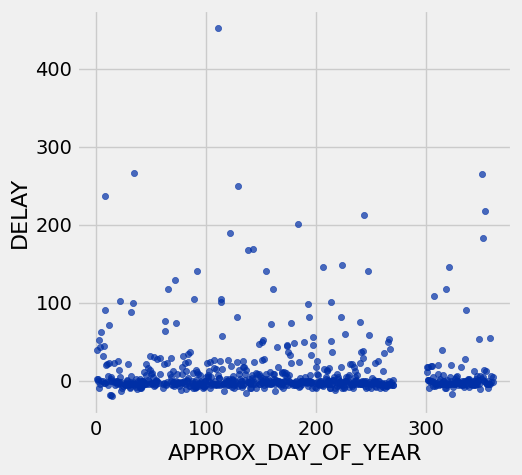

In [ ]:
mySample.scatter('APPROX_DAY_OF_YEAR', 'DELAY')

The plot also shows no obvious seasonal pattern in flight delays. Delays are scattered throughout the approximate days of the year. If there were a seasonal effect, you might expect to see clusters of delays around certain days, but the data does not show this clearly.
